# EX4 — Wall-following: the walls are a better heading reference (when they are there)

**What you will see**
* Two 45° IR sensors reading `raw ≈ A/(d² + c)`: big when a wall is close, ~0 when there is no wall.
* Case (a): P only on `(L − R)` → an S-wiggle that never dies (sensor latency + no damping).
* Case (b): P + D → smooth centring.
* Case (c): the same controller reaching a **missing left wall without any case logic → it steers into the gap.**
* Case (d): with the three-case error and heading hold → straight through the gap.

The rule of the day: *"walls are truth while you can see them; when they vanish, hold the heading with the encoders."*

```
seeL = L > TH ; seeR = R > TH
if seeL/seeR just changed:  blank = BLANK_MM          # ignore the transition (posts, wall ends)
if blank > 0:               hold heading with encoders (diff_ref - diff);  blank -= travelled
elif seeL and seeR:         e_wall = L - R
elif seeL:                  e_wall = 2*(L - L_NOM)
elif seeR:                  e_wall = -2*(R - R_NOM)
else:                       hold heading with encoders
turn = clamp(Kp_wall*e_wall + Kd_wall*d(e_wall)/dt, ±0.3*PWM_MAX)
while walls are seen:  diff_ref = diff                 # re-sync the encoder reference to the walls
```

In [1]:
from mouse_sim import *

cfg = Config()
corr = Corridor(cfg, cells=6, missing=[(2, "L"), (3, "L")])      # left wall missing in cells 2 and 3
sensL = IRSensor(mount=(0.04, +0.04), angle=+math.radians(45), seed=1)
sensR = IRSensor(mount=(0.04, -0.04), angle=-math.radians(45), seed=2)
print(cfg.summary())

counts/rev = 360   counts/mm = 3.58   counts/cell = 645   counts/deg (L-R) = 5.00
passage = 168 mm   clearance per side = 34 mm   battery = 8.4 V / 8.4 V


## 1. What the sensors see — raw value vs distance, and a calibration run down the corridor

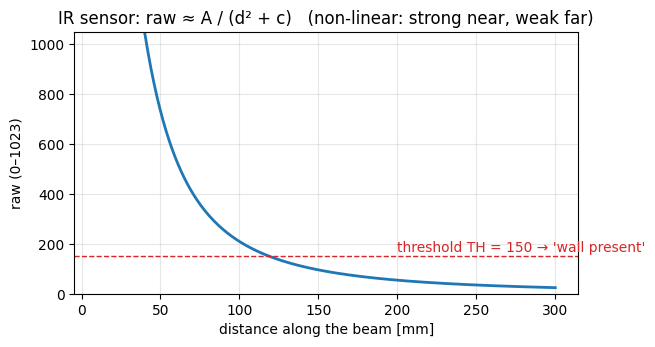

centred, walls both sides: L_NOM = 503, R_NOM = 503;  no wall reads ≈ 26


In [2]:
d = np.linspace(0.01, 0.30, 300)
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(d * 1000, [sensL.A / (x * x + sensL.c) for x in d], lw=2)
ax.axhline(150, color="tab:red", ls="--", lw=1); ax.text(200, 170, "threshold TH = 150 → 'wall present'", color="tab:red")
ax.set_ylim(0, 1050); ax.set_xlabel("distance along the beam [mm]"); ax.set_ylabel("raw (0–1023)")
ax.set_title("IR sensor: raw ≈ A / (d² + c)   (non-linear: strong near, weak far)"); ax.grid(alpha=0.3)
savefig(fig, "ex04_ir_curve.png"); plt.show()

# nominal readings with the mouse perfectly centred (this is your calibration step on the real mouse)
L_NOM = np.mean([sensL.read(corr, (0.10, 0, 0)) for _ in range(50)])
R_NOM = np.mean([sensR.read(corr, (0.10, 0, 0)) for _ in range(50)])
TH = 150
print(f"centred, walls both sides: L_NOM = {L_NOM:.0f}, R_NOM = {R_NOM:.0f};  no wall reads ≈ {sensL.raw_from_distance(0.30):.0f}")

- **High raw value = wall is close. Low raw value = wall is far (or absent).**
  - Formula: `raw = A / (d² + c)` — distance `d` is in the *denominator*. Small `d` → dividing by a small
    number → **big** result. Large `d` → dividing by a big number → **small** result.
  - On the actual curve (`ex04_ir_curve.png`): the line starts near **1023** at the left (small `d`, wall
    right up close) and drops sharply toward **~0** as `d` increases (wall far away or missing).
  - `TH = 150` sits low on that curve: raw values *above* 150 mean "close enough to count as a wall,"
    values *below* 150 mean "nothing there."

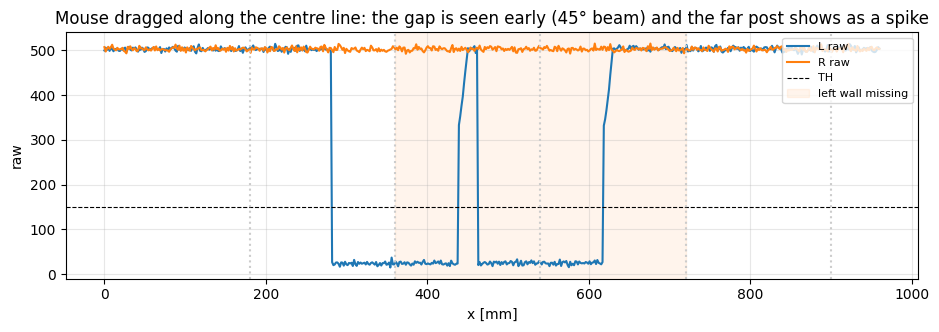

In [3]:
xs = np.linspace(0.0, 6 * cfg.cell - 0.12, 600)
Lraw = [sensL.read(corr, (x, 0, 0)) for x in xs]
Rraw = [sensR.read(corr, (x, 0, 0)) for x in xs]
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(xs * 1000, Lraw, label="L raw"); ax.plot(xs * 1000, Rraw, label="R raw")
ax.axhline(TH, color="k", ls="--", lw=0.8, label="TH")
for k in range(1, 6): ax.axvline(k * cfg.cell * 1000, color="0.8", ls=":")
ax.axvspan(2 * cfg.cell * 1000, 4 * cfg.cell * 1000, color="tab:orange", alpha=0.08, label="left wall missing")
ax.set_xlabel("x [mm]"); ax.set_ylabel("raw"); ax.legend(loc="upper right", fontsize=8); ax.grid(alpha=0.3)
ax.set_title("Mouse dragged along the centre line: the gap is seen early (45° beam) and the far post shows as a spike")
savefig(fig, "ex04_sensor_sweep.png"); plt.show()

**Talking point:** the 45° beam sees the opening ~40 mm *before* the body reaches it and sees the post on the far
side as a short spike. Both must be ignored by the controller — hence the transition blanking.

## 2. The wall-following loop

In [4]:
def run_wall(cfg, corr, kp_w=0.08, kd_w=0.0, case_logic=True, blank_mm=25.0,
             y0=0.02, th0=math.radians(5), fwd_pwm=150, kp_h=2.0, kd_h=0.05,
             t_max=3.0, seed=0, tf=0.02, sensor_hz=100):
    """sensor_hz: how often the IR sensors are actually read (100 Hz = read in the main loop).
    fwd_pwm 150 ≈ 0.7 m/s."""
    m = DiffDrive(cfg, seed=seed)
    m.y, m.theta = y0, th0
    pid_w = PID(kp_w, 0.0, kd_w, tf=tf, umin=-0.3 * cfg.pwm_max, umax=0.3 * cfg.pwm_max)
    pid_h = PID(kp_h, 0.0, kd_h, tf=tf, umin=-0.3 * cfg.pwm_max, umax=0.3 * cfg.pwm_max)
    n = int(t_max / cfg.dt)
    log = {k: np.zeros(n) for k in ("x", "y", "th", "L", "R", "e", "turn", "mode")}
    seeL_prev = seeR_prev = None
    blank = 0.0
    diff_ref = 0
    x_prev = 0.0
    every = max(1, int(round(1.0 / (sensor_hz * cfg.dt))))     # sensors may update slower than the loop
    L = R = 0.0
    for i in range(n):
        if i % every == 0:
            L = sensL.read(corr, m.pose); R = sensR.read(corr, m.pose)
        cL, cR = m.counts; diff = cL - cR
        seeL, seeR = L > TH, R > TH
        mode = 0
        if case_logic:
            if seeL_prev is not None and (seeL != seeL_prev or seeR != seeR_prev):
                blank = blank_mm / 1000.0
            seeL_prev, seeR_prev = seeL, seeR
            blank = max(0.0, blank - abs(m.x - x_prev)); x_prev = m.x
            if blank > 0:
                e, mode = None, 3
            elif seeL and seeR:
                e, mode = L - R, 0
            elif seeL:
                e, mode = 2 * (L - L_NOM), 1
            elif seeR:
                e, mode = -2 * (R - R_NOM), 2
            else:
                e, mode = None, 3
        else:
            e = L - R                                   # naive: always trust (L - R)
        if e is None:                                   # hold heading with the encoders
            turn = pid_h.update(diff_ref - diff, cfg.dt)
        else:
            turn = pid_w.update(e, cfg.dt)
            diff_ref = diff                             # walls are truth: re-sync the encoder reference
            pid_h.reset()
        m.step(fwd_pwm + turn, fwd_pwm - turn)
        for k, v in zip(log, (m.x, m.y, m.theta, L, R, 0 if e is None else e, turn, mode)):
            log[k][i] = v
        if m.x > 6 * cfg.cell - 0.15 or abs(m.y) > cfg.passage / 2:
            for k in log: log[k] = log[k][: i + 1]
            break
    return log

### Sign check
Mouse too close to the **left** wall → `L` large → `e = L − R > 0` → we need to turn **right** → `turn > 0`
→ `pwmL = fwd + turn` bigger than `pwmR`. (If it turns the wrong way on your mouse, flip the sign once.)

## 3. Cases (a) and (b) in a corridor with both walls — gain too high vs P + D

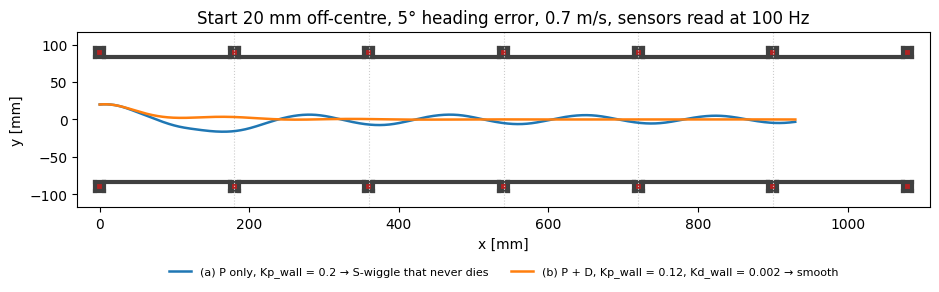

In [5]:
corr_full = Corridor(cfg, cells=6)
a = run_wall(cfg, corr_full, kp_w=0.2,  kd_w=0.0)
b = run_wall(cfg, corr_full, kp_w=0.12, kd_w=0.002)

fig, ax = plt.subplots(figsize=(11, 3.4))
plot_topview(ax, cfg, [
    ("(a) P only, Kp_wall = 0.2 → S-wiggle that never dies", a["x"], a["y"]),
    ("(b) P + D, Kp_wall = 0.12, Kd_wall = 0.002 → smooth", b["x"], b["y"]),
], corridor=corr_full, title="Start 20 mm off-centre, 5° heading error, 0.7 m/s, sensors read at 100 Hz", show_body=False)
savefig(fig, "ex04_case_ab_topview.png"); plt.show()

**Talking point:** the sensors are read at 100 Hz while the mouse moves 7 mm per reading. That latency is what
makes wall-following oscillate; D (or reading the sensors faster) is the cure. Try `sensor_hz=1000` below —
the wiggle disappears even without D.

## 4. Case (c): no case logic, left wall disappears → it turns into the gap
The naive controller keeps computing `e = L − R`. In the gap `L ≈ 0`, so `e ≈ −R` = "I am far from the left wall,
steer left". It does exactly what it was told.

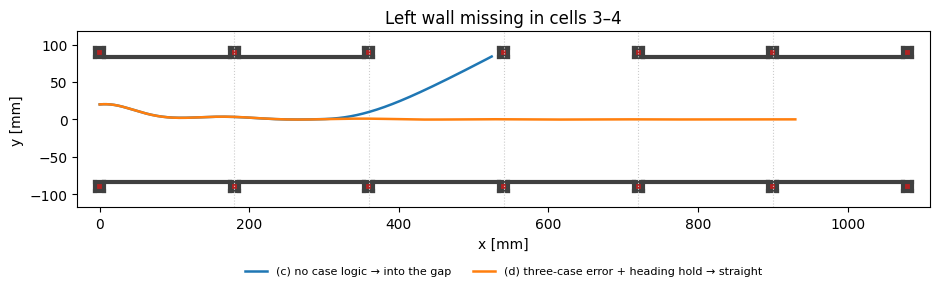

(c) leaves the corridor at x = 524 mm
(d) ends at y = +0.0 mm


In [6]:
c = run_wall(cfg, corr, kp_w=0.12, kd_w=0.002, case_logic=False)
d_ = run_wall(cfg, corr, kp_w=0.12, kd_w=0.002, case_logic=True)

fig, ax = plt.subplots(figsize=(11, 3.4))
plot_topview(ax, cfg, [
    ("(c) no case logic → into the gap", c["x"], c["y"]),
    ("(d) three-case error + heading hold → straight", d_["x"], d_["y"]),
], corridor=corr, title="Left wall missing in cells 3–4", show_body=False)
savefig(fig, "ex04_case_cd_topview.png"); plt.show()
print(f"(c) leaves the corridor at x = {c['x'][-1]*1000:.0f} mm" if abs(c['y'][-1]) > cfg.passage/2 - 0.001 else f"(c) ends at y = {c['y'][-1]*1000:+.0f} mm")
print(f"(d) ends at y = {d_['y'][-1]*1000:+.1f} mm")

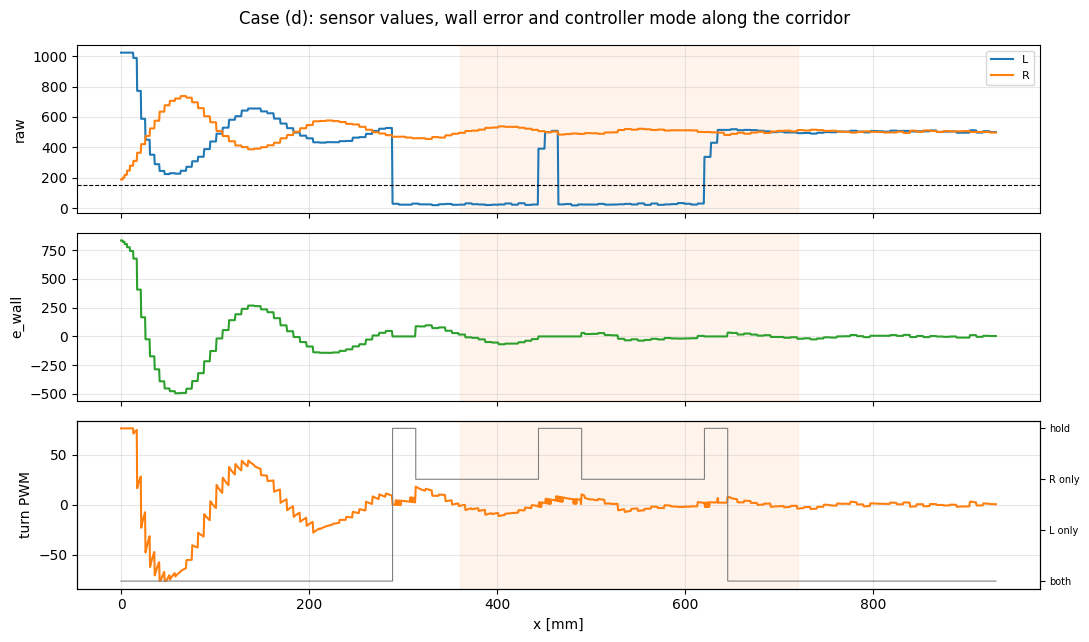

In [7]:
xd = d_["x"] * 1000
fig, axes = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)
axes[0].plot(xd, d_["L"], label="L"); axes[0].plot(xd, d_["R"], label="R"); axes[0].axhline(TH, color="k", ls="--", lw=0.8)
axes[0].set_ylabel("raw"); axes[0].legend(fontsize=8, loc="upper right")
axes[1].plot(xd, d_["e"], color="tab:green"); axes[1].set_ylabel("e_wall")
axes[2].plot(xd, d_["turn"], color="tab:orange", label="turn"); axes[2].set_ylabel("turn PWM")
ax2 = axes[2].twinx(); ax2.step(xd, d_["mode"], color="0.5", lw=0.8, where="post"); ax2.set_yticks([0, 1, 2, 3]); ax2.set_yticklabels(["both", "L only", "R only", "hold"], fontsize=7)
for ax in axes:
    ax.axvspan(2 * cfg.cell * 1000, 4 * cfg.cell * 1000, color="tab:orange", alpha=0.08); ax.grid(alpha=0.3)
axes[2].set_xlabel("x [mm]"); fig.suptitle("Case (d): sensor values, wall error and controller mode along the corridor")
fig.tight_layout(); savefig(fig, "ex04_case_d_signals.png"); plt.show()

**Talking points**
* Mode switches `both → hold → R only → hold → both` across the gap. During `hold` the encoders keep the heading
  the walls last agreed on.
* The wall term is capped at 30 % of PWM: a wall touch that stalls the mouse means a manual reset (score penalty)
  and the rulebook forbids wall damage.

## 5. GIF for the slides: case (c) vs (d)

In [8]:
gif = animate_topview(cfg, d_["x"], d_["y"], d_["th"], "figures/ex04_gap_with_logic.gif", corridor=corr,
                      title="Wall-following with three-case error + heading hold",
                      extra_traces=[("(c) no case logic", c["x"], c["y"])])
print("saved", gif)

saved figures/ex04_gap_with_logic.gif


## Try this
* `sensor_hz=1000` in case (a): the oscillation goes away without D. `sensor_hz=50`: even P + D struggles.
* `blank_mm=0` — what happens at the post spike?  `blank_mm=80` — it holds too long and drifts.
* `y0=-0.02` (start near the right wall) — the sign logic must still work.
* Add `sigma=20` noise in `IRSensor` — now `kd_w` starts to hurt (noise) → filter or drop D.

## On your mouse
* Calibrate at the venue: centred → record `L_NOM, R_NOM`; no wall → record the floor value; `TH` halfway.
  Ambient IR (sunlight, hall lights) changes these.
* If your sensors point straight sideways (90°), the post spike appears *inside* gaps instead of before them —
  the blanking rule still applies.
* Keep the wall term capped; if the mouse "leans" on walls, lower `Kp_wall` before anything else.